# Section 4: Recommend Songs to User

In this notebook, we will use our kmeans model to recommend songs to a user.

1. Refit PCA and KMeans on Training Data
2. Load User Listening History (`recommend.csv`)
3. Predict Cluster Labels
5. Identify User's Top 3 Dominant Clusters (Taste Profile)
5. Generate Recommendations
8. Save Output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

# Style for visuals
PALETTE = sns.color_palette('husl', 15)
plt.style.use('dark_background')

In [2]:
PALETTE = sns.color_palette('husl', 15)
plt.style.use('dark_background')

LYRICAL_COLS = [
    'dating', 'violence', 'world/life', 'night/time', 'shake the audience',
    'family/gospel', 'romantic', 'communication', 'obscene', 'music',
    'movement/places', 'light/visual perceptions', 'family/spiritual',
    'sadness', 'feelings'
]

CLUSTER_NAMES = {
    0: 'Dark / Aggressive',
    1: 'Music About Music',
    2: 'Explicit / Hip-Hop',
    3: 'Love Songs',
    4: 'Nightlife / Time-Themed',
    5: 'Melancholic',
    6: 'Reflective / Philosophical'
}

## 1. Refit PCA and KMeans on Training Data

We refit using the exact same parameters as Notebooks 2 and 3. This gives us the same PCA space and cluster centroids, so new songs land in the correct positions.

In [3]:
# Load cleaned training data (output of Notebook 2)
df_train = pd.read_csv('../data/cleaned_data/cleaned_train.csv')
X_train = df_train[LYRICAL_COLS].values

# Refit PCA — same parameters as Notebook 2
pca = PCA(n_components=7, random_state=42)
X_pca_train = pca.fit_transform(X_train)

# Refit KMeans — same parameters as Notebook 3
kmeans = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_pca_train)

# Verify: labels must match clustered_train.csv exactly
saved_labels = pd.read_csv('../data/clustered_data/clustered_train.csv')['cluster'].values
match = (kmeans.labels_ == saved_labels).all()


print(f'Labels match clustered_train.csv: {match}')  # must be True
print(f'Training songs: {len(X_train):,}')

Labels match clustered_train.csv: True
Training songs: 28,362


## 2. Load User Listening History (`recommend.csv`)

In [4]:
df_rec = pd.read_csv('../data/recommend.csv')

print(f'Shape: {df_rec.shape}') #10 songs, 25 columns -- there's an extra column
df_rec.head()

Shape: (10, 25)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,obscene,music,movement/places,light/visual perceptions,family/spiritual,like/girls,sadness,feelings,topic,age
0,76885,godsmack,immune,1998,rock,come world society futher place home land deat...,74,0.000907,0.348191,0.375448,...,0.000907,0.019389,0.000907,0.000907,0.000907,0.000907,0.000907,0.018854,world/life,0.314286
1,65394,dennis brown,second chance,1993,reggae,maybe maybe treat good feel second best girl s...,43,0.001224,0.029943,0.001224,...,0.001224,0.001224,0.001224,0.001224,0.001224,0.056842,0.001224,0.062092,night/time,0.385714
2,10980,the black crowes,sister luck,1990,pop,worry sick eye hurt rest head life outside gir...,54,0.001120,0.482490,0.001120,...,0.001120,0.001120,0.001120,0.078222,0.001120,0.051132,0.031571,0.202862,violence,0.428571
3,842,jerry lee lewis,your cheating heart,1960,pop,cheat heart weep sleep sleep come night cheat ...,25,0.204740,0.002506,0.002506,...,0.002506,0.002506,0.002506,0.002506,0.002506,0.002506,0.474607,0.002506,sadness,0.857143
4,2764,paul anka,eso beso,1966,pop,beso kiss beso kiss know samba bossanova close...,97,0.001170,0.001170,0.001170,...,0.001170,0.001170,0.001170,0.314626,0.001170,0.053731,0.001170,0.001170,romantic,0.771429


## 3. Predict Cluster Labels

In [5]:
X_rec = df_rec[LYRICAL_COLS].values # Only use same 15 lyrical features used in training

X_rec_pca = pca.transform(X_rec) # Transform using the training PCA (no refit)

print(f'Recommend feature matrix shape: {X_rec_pca.shape}')

# Predict cluster labels using the trained KMeans model
labels = kmeans.predict(X_rec_pca) 

df_rec['cluster'] = labels # Attach cluster labels to the recommend dataset
df_rec['cluster_name'] = df_rec['cluster'].map(CLUSTER_NAMES)

df_rec[['artist_name', 'track_name', 'genre', 'cluster', 'cluster_name']]

Recommend feature matrix shape: (10, 7)


,artist_name,track_name,genre,cluster,cluster_name
0,godsmack,immune,rock,2,Explicit / Hip-Hop
1,dennis brown,second chance,reggae,6,Reflective / Philosophical
2,the black crowes,sister luck,pop,0,Dark / Aggressive
3,jerry lee lewis,your cheating heart,pop,5,Melancholic
4,paul anka,eso beso,pop,3,Love Songs
5,noro morales,silencio,jazz,0,Dark / Aggressive
6,rage against the machine,pistol grip pump,rock,4,Nightlife / Time-Themed
7,taste,railway and gun,blues,5,Melancholic
8,randy travis,messin' with my mind,country,6,Reflective / Philosophical
9,paramore,playing god,pop,0,Dark / Aggressive


## 4. Identify User's Top 3 Dominant Clusters (Taste Profile)

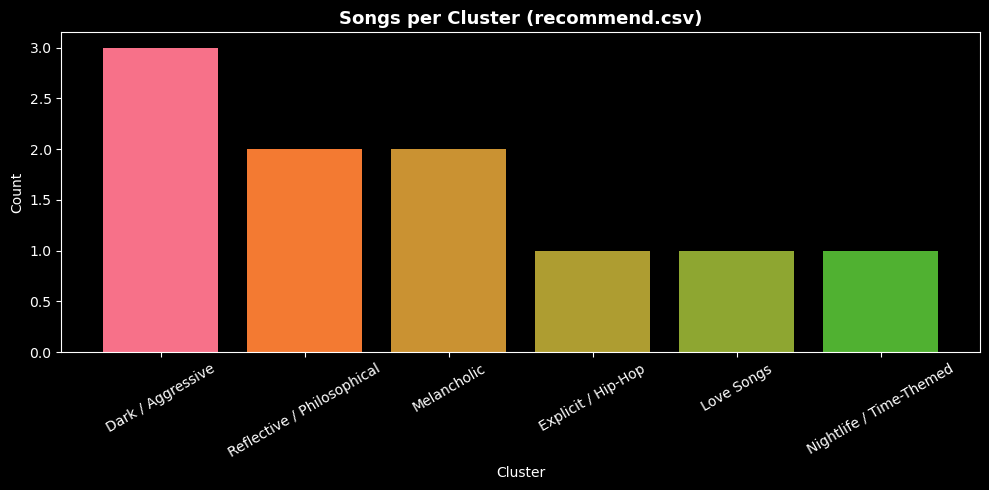

In [6]:
cluster_counts = df_rec['cluster'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    [CLUSTER_NAMES[c] for c in cluster_counts.index], 
    cluster_counts.values,
    color=PALETTE[:len(cluster_counts)]
)
ax.set_title('Songs per Cluster (recommend.csv)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [7]:
top_3_clusters = cluster_counts.head(3)

print("User's top 3 dominant clusters (taste profile) & count of songs in listening history:")
print()
for cluster_id, count in top_3_clusters.items():
    print(f'  Cluster {cluster_id}: {CLUSTER_NAMES[cluster_id]} = {count} songs')

User's top 3 dominant clusters (taste profile) & count of songs in listening history:

  Cluster 0: Dark / Aggressive = 3 songs
  Cluster 6: Reflective / Philosophical = 2 songs
  Cluster 5: Melancholic = 2 songs


## 5. Generate Recommendations

For each of the user's top 3 clusters, we pull 5 songs from `clustered_train.csv` that belong to that cluster. These are songs the user has never heard that match their listening taste.

In [8]:
def generate_recommendations(rec_df, top_clusters, n=5):
    """Generate song recommendations based on user's top clusters."""
    
    clustered_train = pd.read_csv('../data/clustered_data/clustered_train.csv')
    
    # Exclude songs already in the user's listening history
    history_tracks = set(rec_df['track_name'].str.lower())
    unseen = clustered_train[~clustered_train['track_name'].str.lower().isin(history_tracks)]
    
    all_recs = []
    print('Recommendations based on listening history:')
    print()
    
    for cluster_id in top_clusters.index:
        pool = unseen[unseen['cluster'] == cluster_id] # Only recommend from the same cluster
        recs = pool[['artist_name', 'track_name', 'genre']].sample(n, random_state=42) # Randomly sample n recommendations from the cluster
        recs['cluster'] = cluster_id
        recs['cluster_name'] = CLUSTER_NAMES[cluster_id]
        all_recs.append(recs) 
        
        print(f'{CLUSTER_NAMES[cluster_id]} (Cluster {cluster_id}) — {len(pool):,} songs available:')
        print(recs[['artist_name', 'track_name', 'genre']])
        print()
    
    return pd.concat(all_recs, ignore_index=True) # Combine recommendations from all top clusters into a single DataFrame

In [9]:
# Generate recommendations based on the user's top 3 clusters
recommendations_df = generate_recommendations(df_rec, top_3_clusters)

Recommendations based on listening history:

Dark / Aggressive (Cluster 0) — 5,764 songs available:
          artist_name        track_name   genre
22286          sizzla      no white god  reggae
24565            rush         losing it    rock
13947    dr. feelgood  milk and alcohol   blues
20851  joey alexander    draw me nearer    jazz
24748   mercyful fate              evil    rock

Reflective / Philosophical (Cluster 6) — 2,073 songs available:
          artist_name            track_name    genre
19394           unkle                unreal     jazz
17051  the raconteurs  what's yours is mine    blues
23750       the doors      end of the night     rock
7685       bobby bare         when i'm gone  country
12717     ray charles        the right time    blues

Melancholic (Cluster 5) — 6,122 songs available:
             artist_name             track_name    genre
8241     the youngbloods              beautiful  country
14646         the cramps          lonesome town    blues
7329    

## 7. Save Output

In [11]:
# Save recommend dataset WITH cluster labels for future analysis
df_rec.to_csv('../data/clustered_data/clustered_recommend.csv', index=False)
print('Saved: ../data/clustered_recommend.csv')

df_rec[['artist_name', 'track_name', 'genre', 'cluster', 'cluster_name']]


Saved: ../data/clustered_recommend.csv


,artist_name,track_name,genre,cluster,cluster_name
0,godsmack,immune,rock,2,Explicit / Hip-Hop
1,dennis brown,second chance,reggae,6,Reflective / Philosophical
2,the black crowes,sister luck,pop,0,Dark / Aggressive
3,jerry lee lewis,your cheating heart,pop,5,Melancholic
4,paul anka,eso beso,pop,3,Love Songs
5,noro morales,silencio,jazz,0,Dark / Aggressive
6,rage against the machine,pistol grip pump,rock,4,Nightlife / Time-Themed
7,taste,railway and gun,blues,5,Melancholic
8,randy travis,messin' with my mind,country,6,Reflective / Philosophical
9,paramore,playing god,pop,0,Dark / Aggressive


In [10]:
# Save the recommendations to a CSV file
recommendations_df.to_csv('../data/recommendations.csv', index=False)
print('Saved: ../data/recommendations.csv')

Saved: ../data/recommendations.csv


This notebook generated recommendations and two files:


Future Improvement for this recommendation engine:
- use cluster distance
